In [23]:
import os

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from numba import njit, prange
from scipy.ndimage import gaussian_filter

In [24]:
colors = np.linspace(0, 1, 5)
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=plt.cm.rainbow(colors))

os.makedirs("../img", exist_ok=True)

# Algorithm 4 Sample-based Policy Iteration for Exploratory Optimal Stopping (SPI-λ-OS)

## Parameters

In [25]:
mu = 0.2
sigma = 0.2
rho = 0.5
kappa = 5.0
theta = 0.5
lambda_ = 0.2
zeta = 0.9

Nx = 250
Ny = 50
M = 20
T_max = 20
dt = 0.01

x_max = 5
x_grid = np.linspace(1e-4, x_max, Nx)
y_grid = np.linspace(1e-4, 1.0, Ny)

dx = x_grid[1] - x_grid[0]
dy = y_grid[1] - y_grid[0]

## Algorithm functions

In [26]:
@njit
def pi(x: float) -> float:
    return x**theta

In [27]:
@njit
def simulator_core(
    x_start: float,
    y_start: float,
    x_grid: np.ndarray,
    g: np.ndarray,
    M: int,
    dt: float,
    T_max: float,
    mu: float,
    sigma: float,
    rho: float,
    kappa: float,
    lambda_: float,
    theta: float,
    variant: int,
    Z: np.ndarray,
) -> float:
    """
    Simulate the core dynamics of the system.
    Corresponds to lines 4, 5, 6 and 7 in the algorithm from the article.

    Parameters:
    x_start: Starting value of the state variable X.
    y_start: Starting value of the state variable Y.
    x_grid: Grid of X values for interpolation.
    g: Array of g values corresponding to x_grid.
    M: Number of Monte Carlo simulations.
    dt: Time step for the simulation.
    T_max: Maximum time for the simulation.
    mu: Drift coefficient for X.
    sigma: Volatility coefficient for X.
    rho: Discount rate.
    kappa: Parameter for the reward function.
    lambda_: Parameter for the reward function.
    theta: Parameter for the reward function.
    variant: Variant of the model to use (1 or 2).
    Z: Pre-generated random numbers for the simulation.

    Returns:
    Average payoff over M simulations.
    """
    total_payoff = 0.0
    steps = int(T_max / dt)
    sqrt_dt = np.sqrt(dt)
    exp_neg_rho_dt = np.exp(-rho * dt)

    for m in range(M):
        X = x_start
        Y = y_start

        current_g = np.interp(X, x_grid, g)
        if Y > current_g:
            Y = current_g

        discount = 1.0
        path_payoff = 0.0

        for step_idx in range(steps):
            Y_safe = Y if Y > 1e-8 else 1e-8
            reward = ((pi(X) - rho * kappa) * Y - lambda_ * Y * np.log(Y_safe)) * dt
            path_payoff += discount * reward

            discount *= exp_neg_rho_dt

            dW = Z[m, step_idx]

            X = X + mu * X * dt + sigma * X * dW * sqrt_dt

            current_g = np.interp(X, x_grid, g)
            if Y > current_g:
                Y = current_g

        total_payoff += path_payoff

    return total_payoff / M

In [28]:
@njit(parallel=True)
def evaluate_u_monte_carlo(
    g: np.ndarray,
    x_grid: np.ndarray,
    y_grid: np.ndarray,
    M: int,
    dt: float,
    T_max: float,
    mu: float,
    sigma: float,
    rho: float,
    kappa: float,
    lambda_: float,
    theta: float,
    variant: int,
    Z: np.ndarray,
) -> np.ndarray:
    """
    Evaluate the function u over a grid of x and y values using Monte Carlo simulations.
    Corresponds to line 3 in the algorithm from the article.

    Parameters:
    g: Array of g values corresponding to x_grid.
    x_grid: Grid of X values for interpolation.
    y_grid: Grid of Y values for interpolation.
    M: Number of Monte Carlo simulations.
    dt: Time step for the simulation.
    T_max: Maximum time for the simulation.
    mu: Drift coefficient for X.
    sigma: Volatility coefficient for X.
    rho: Discount rate.
    kappa: Parameter for the reward function.
    lambda_: Parameter for the reward function.
    theta: Parameter for the reward function.
    variant: Variant of the simulation (1 or 2).
    Z: Pre-generated random numbers for the simulation.

    Returns:
    2D array of u values evaluated over the grid of x and y.
    """
    Nx = len(x_grid)
    Ny = len(y_grid)
    u = np.zeros((Nx, Ny))

    for i in prange(Nx):
        for j in range(Ny):
            u[i, j] = simulator_core(
                x_grid[i],
                y_grid[j],
                x_grid,
                g,
                M,
                dt,
                T_max,
                mu,
                sigma,
                rho,
                kappa,
                lambda_,
                theta,
                variant,
                Z,
            )
    return u

In [29]:
def policy_improvement(
    u: np.ndarray,
    g: np.ndarray,
    iteration: int,
    K: int,
    variant: str,
    tolerance: float = 1e-5,
) -> np.ndarray:
    """
    Improve the policy based on the current value function.
    Corresponds to line 9 in the algorithm from the article.

    Parameters:
    u: 2D array of the current value function evaluated over the grid of x and y.
    g: Array of current g values corresponding to x_grid.
    iteration: Current iteration number.
    K: Total number of iterations.
    variant: Variant of the simulation (1 or 2).
    tolerance: Tolerance level for detecting sign changes in the second derivative.

    Returns:
    Updated array of g values after policy improvement.
    """
    g_new = g.copy()

    current_sigma_u = 3.0 - (2.5 * (iteration / K))

    u_smooth = gaussian_filter(u, sigma=current_sigma_u)
    ux = np.gradient(u_smooth, dx, axis=0)
    uxy = np.gradient(ux, dy, axis=1)

    for i in range(Nx):
        j_boundary = np.searchsorted(y_grid, g[i], side="left") - 1
        j_boundary = max(j_boundary, 0)

        if uxy[i, j_boundary] < -tolerance:
            sign_change = np.where(np.diff(np.sign(uxy[i, :])))[0]
            valid = [j for j in sign_change if y_grid[j] < g[i]]

            if len(valid) > 0:
                j_target = max(valid)

                y1 = y_grid[j_target]
                y2 = y_grid[j_target + 1]

                f1 = uxy[i, j_target]
                f2 = uxy[i, j_target + 1]

                if abs(f2 - f1) > 1e-12:
                    g_new[i] = y1 - f1 * (y2 - y1) / (f2 - f1)
                else:
                    g_new[i] = y1

                g_new[i] = max(min(g_new[i], y2), y1)

    # Optional: smoothing of the boundary, gives pretty plots, but less accurate results, so commented out
    # current_sigma_g = 1.0 * (1 - iteration/K)
    # if current_sigma_g > 0.1:
    #     g = gaussian_filter(g_new, sigma=current_sigma_g)

    if variant == 1:
        for idx in range(1, len(g_new)):
            g_new[idx] = max(g_new[idx], g_new[idx - 1])

    g_new = np.clip(g_new, 0, 1.0)
    g_new[g_new > 0.98] = 1.0

    return g_new

In [30]:
def policy_iteration_MC(
    g0: callable, func_g_true: callable, variant: int = 1, K: int = 10, M: int = 100
) -> tuple[list[np.ndarray], np.ndarray, list[float]]:
    """
    Perform policy iteration using Monte Carlo simulations.
    Corresponds to lines 1 and 2 in the algorithm from the article.

    Parameters:
    g0: Callable that returns the initial guess for g.
    func_g_true: Callable that returns the true g values for error calculation.
    variant: Variant of the simulation (1 or 2).
    K: Total number of policy iteration steps.
    M: Number of Monte Carlo simulations for evaluating u.

    Returns:
    gs: List of g values at each iteration.
    g: Final g values after policy iteration.
    errors_g_true: List of maximum absolute errors between g and the true g values at each iteration.
    """
    g = g0()
    gs = [g.copy()]
    errors_g_true = []
    steps = int(T_max / dt)

    for k in range(K):
        Z = np.random.normal(0.0, 1.0, (M, steps))

        u = evaluate_u_monte_carlo(
            g,
            x_grid,
            y_grid,
            M,
            dt,
            T_max,
            mu,
            sigma,
            rho,
            kappa,
            lambda_,
            theta,
            variant,
            Z,
        )
        g = policy_improvement(u, g, k, K, variant)

        gs.append(g.copy())

        diff_mean = np.mean(np.abs(g - gs[-2]))
        error_g_true = np.max(np.abs(g - func_g_true()))
        errors_g_true.append(error_g_true)

        if diff_mean < 0.001:
            print(f"Converged at iteration {k+1}")
            break

    return gs, g, errors_g_true

## Examples of initialization functions

In [31]:
def func_g_true():
    g = np.zeros_like(x_grid)

    P = rho - theta * mu - (sigma**2) * theta * (theta - 1) / 2
    alfa = (
        -(mu - sigma**2 / 2) - np.sqrt((mu - sigma**2 / 2) ** 2 + 2 * rho * sigma**2)
    ) / (sigma**2)
    for i, x in enumerate(x_grid):
        g[i] = min(
            np.exp((rho / lambda_) * ((x**theta / P) * (1 - theta / alfa) - kappa) - 1),
            1.0,
        )

    return g

In [32]:
def func_linear():
    g = np.zeros_like(x_grid)
    base = np.exp(-(1 + kappa * rho / lambda_))
    alpha = (
        -(mu - sigma**2 / 2) - np.sqrt((mu - sigma**2 / 2) ** 2 + 2 * rho * sigma**2)
    ) / (sigma**2)

    x1 = 0.5 * (-alpha * (kappa + lambda_ / rho) / (theta - alpha)) ** (-theta)

    for i, x in enumerate(x_grid):
        g[i] = min(base + (1.0 - base) / x1 * x, 1.0)
    return g

In [33]:
def func_exponential():
    g = np.zeros_like(x_grid)

    P = rho - zeta * mu - (sigma**2) * zeta * (zeta - 1) / 2
    alfa = (
        -(mu - sigma**2 / 2) - np.sqrt((mu - sigma**2 / 2) ** 2 + 2 * rho * sigma**2)
    ) / (sigma**2)

    for i, x in enumerate(x_grid):
        g[i] = min(
            np.exp((rho / lambda_) * ((x**zeta / P) * (1 - zeta / alfa) - kappa) - 1),
            1.0,
        )
    return g

In [34]:
def func_proposed():
    base = np.exp(-(1 + kappa * rho / lambda_))
    g = np.zeros_like(x_grid)

    for i, x in enumerate(x_grid):
        g[i] = min(base + x**2, 1.0)

    return g

## Outcome functions

In [35]:
def plot_results(
    gs: list[np.ndarray], g_final_0: np.ndarray, g_true_vals: np.ndarray, title: str
) -> None:
    """
    Plot the results of the policy iteration, including the true boundary, initial guess, K/2 iteration, and final boundary.

    Parameters:
    gs: A list of g values at each iteration.
    g_final_0: The final boundary g after convergence.
    g_true_vals: The true boundary values for comparison.
    title: The title for the plot.
    """
    K = len(gs) - 1

    plt.plot(
        x_grid,
        g_true_vals,
        color="gray",
        linestyle="--",
        linewidth=2,
        label="g_true (Analityczne)",
    )
    plt.plot(x_grid, gs[0], label="g_0(x)", linestyle="dashed", color="red")

    # Optional: plotting graphs for each iteration
    # for i in range(1, len(gs) - 1):
    #     plt.plot(x_grid, gs[i], alpha=0.4)

    # Graph for iteration K//2
    if K > 2:
        mid_k = K // 2
        plt.plot(
            x_grid, gs[mid_k], label=f"g(x) iter {mid_k}", color="orange", alpha=0.7
        )

    plt.plot(x_grid, g_final_0, label="g(x) final", linewidth=2, color="black")

    plt.xlabel("x")
    plt.ylabel("g(x)")
    plt.xlim(0, x_max)
    plt.title(title)
    plt.grid(True)
    plt.legend()

In [36]:
def plot_L1_error(gs: list, dx: float) -> None:
    """
    Plot the L1 error of the policy iteration.

    Parameters:
    gs: A list of g values at each iteration.
    dx: The step size for the discretization.
    """
    g_true_vals = func_g_true()
    gs_ = gs[1:]

    l1_errors = []

    for g_iter in gs_:
        error = np.sum(np.abs(g_iter - g_true_vals)) * dx
        l1_errors.append(error)

    plt.plot(
        range(1, len(l1_errors) + 1), l1_errors, marker="o", linestyle="-", color="blue"
    )
    plt.title("Convergence to g_true in the L1 norm")
    plt.xlabel("iteration")
    plt.ylabel("L1 error")

    plt.xticks(np.arange(1, len(l1_errors) + 1, 2))

    plt.grid(True)

In [37]:
def find_hitting_point(
    g_array: np.ndarray, x_array: np.ndarray, threshold: float = 0.999
) -> float:
    """
    Find the x value where g_array first reaches or exceeds the threshold.

    Parameters:
    g_array: The array of g values.
    x_array: The corresponding x values.
    threshold: The threshold value to find the hitting point.

    Returns:
    The x value where g_array first reaches or exceeds the threshold. Returns NaN if the threshold is not reached.
    """
    idx = np.argmax(g_array >= threshold)
    if idx == 0 and g_array[0] < threshold:
        return np.nan
    return x_array[idx]

## Function that runs the algorithm for different variants

In [38]:
def run_algorithm_4(
    g0_func: callable, func_true: callable, K: int, M: int, title_prefix: str
) -> None:
    """
    Run the policy iteration algorithm for two variants and plot the results.

    Parameters:
    g0_func: A callable that returns the initial guess for g.
    func_true: A callable that returns the true g values for comparison.
    K: The maximum number of iterations for policy iteration.
    M: The number of Monte Carlo samples.
    title_prefix: A string prefix for the plot titles.

    Variants:
    1: Conditions as proposed in the article.
    2: No imposed monotonicity for better visibility of the results.
    """

    g_true_vals = func_true()
    true_hit_1 = find_hitting_point(g_true_vals, x_grid)

    plt.figure(figsize=(18, 15))

    for variant in [1, 2]:
        print(f"Running calculations: {title_prefix} | Variant {variant}...")
        gs, g_final, errors = policy_iteration_MC(
            g0_func, func_true, variant=variant, K=K, M=M
        )

        # Calculating L1 errors
        l1_errors = [np.sum(np.abs(g_iter - g_true_vals)) * dx for g_iter in gs[1:]]
        final_l1 = l1_errors[-1]

        # Finding hitting point
        model_hit_1 = find_hitting_point(g_final, x_grid)

        # Plotting the boundary graph
        plt.subplot(2, 2, variant)
        var_title = ["Conditions from the article", "No imposed monotonicity"][
            variant - 1
        ]
        plot_results(gs, g_final, g_true_vals, f"Variant {variant}: {var_title}")

        # Plotting the L1 error
        plt.subplot(2, 2, variant + 2)
        plt.plot(
            range(1, len(l1_errors) + 1),
            l1_errors,
            marker="o",
            linestyle="-",
            color="blue",
        )
        plt.title(f"L1 Error (Variant {variant})")
        plt.xlabel("Iteration")
        plt.ylabel("L1 error")
        plt.grid(True)

        # Log output
        print(f"--- RESULTS FOR VARIANT {variant} ---")
        print(f"Final L1 error:      {final_l1:.6f}")
        print(
            f"g_true reaches 1 at:    X = {true_hit_1:.4f}"
            if not np.isnan(true_hit_1)
            else "g_true does not reach 1."
        )
        print(
            f"Model reaches 1 at:     X = {model_hit_1:.4f}"
            if not np.isnan(model_hit_1)
            else "Model does not reach 1."
        )
        print("-" * 35)

    plt.tight_layout()

    filename = f"algorithm_4_{title_prefix.replace(' ', '_')}_results.png"
    save_path = os.path.join("../img", filename)

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

## Results

### analytical initialization

Running calculations: analitycal initialization | Variant 1...
Converged at iteration 1
--- RESULTS FOR VARIANT 1 ---
Final L1 error:      0.000193
g_true reaches 1 at:    X = 4.3976
Model reaches 1 at:     X = 4.3775
-----------------------------------
Running calculations: analitycal initialization | Variant 2...
Converged at iteration 1
--- RESULTS FOR VARIANT 2 ---
Final L1 error:      0.000193
g_true reaches 1 at:    X = 4.3976
Model reaches 1 at:     X = 4.3775
-----------------------------------


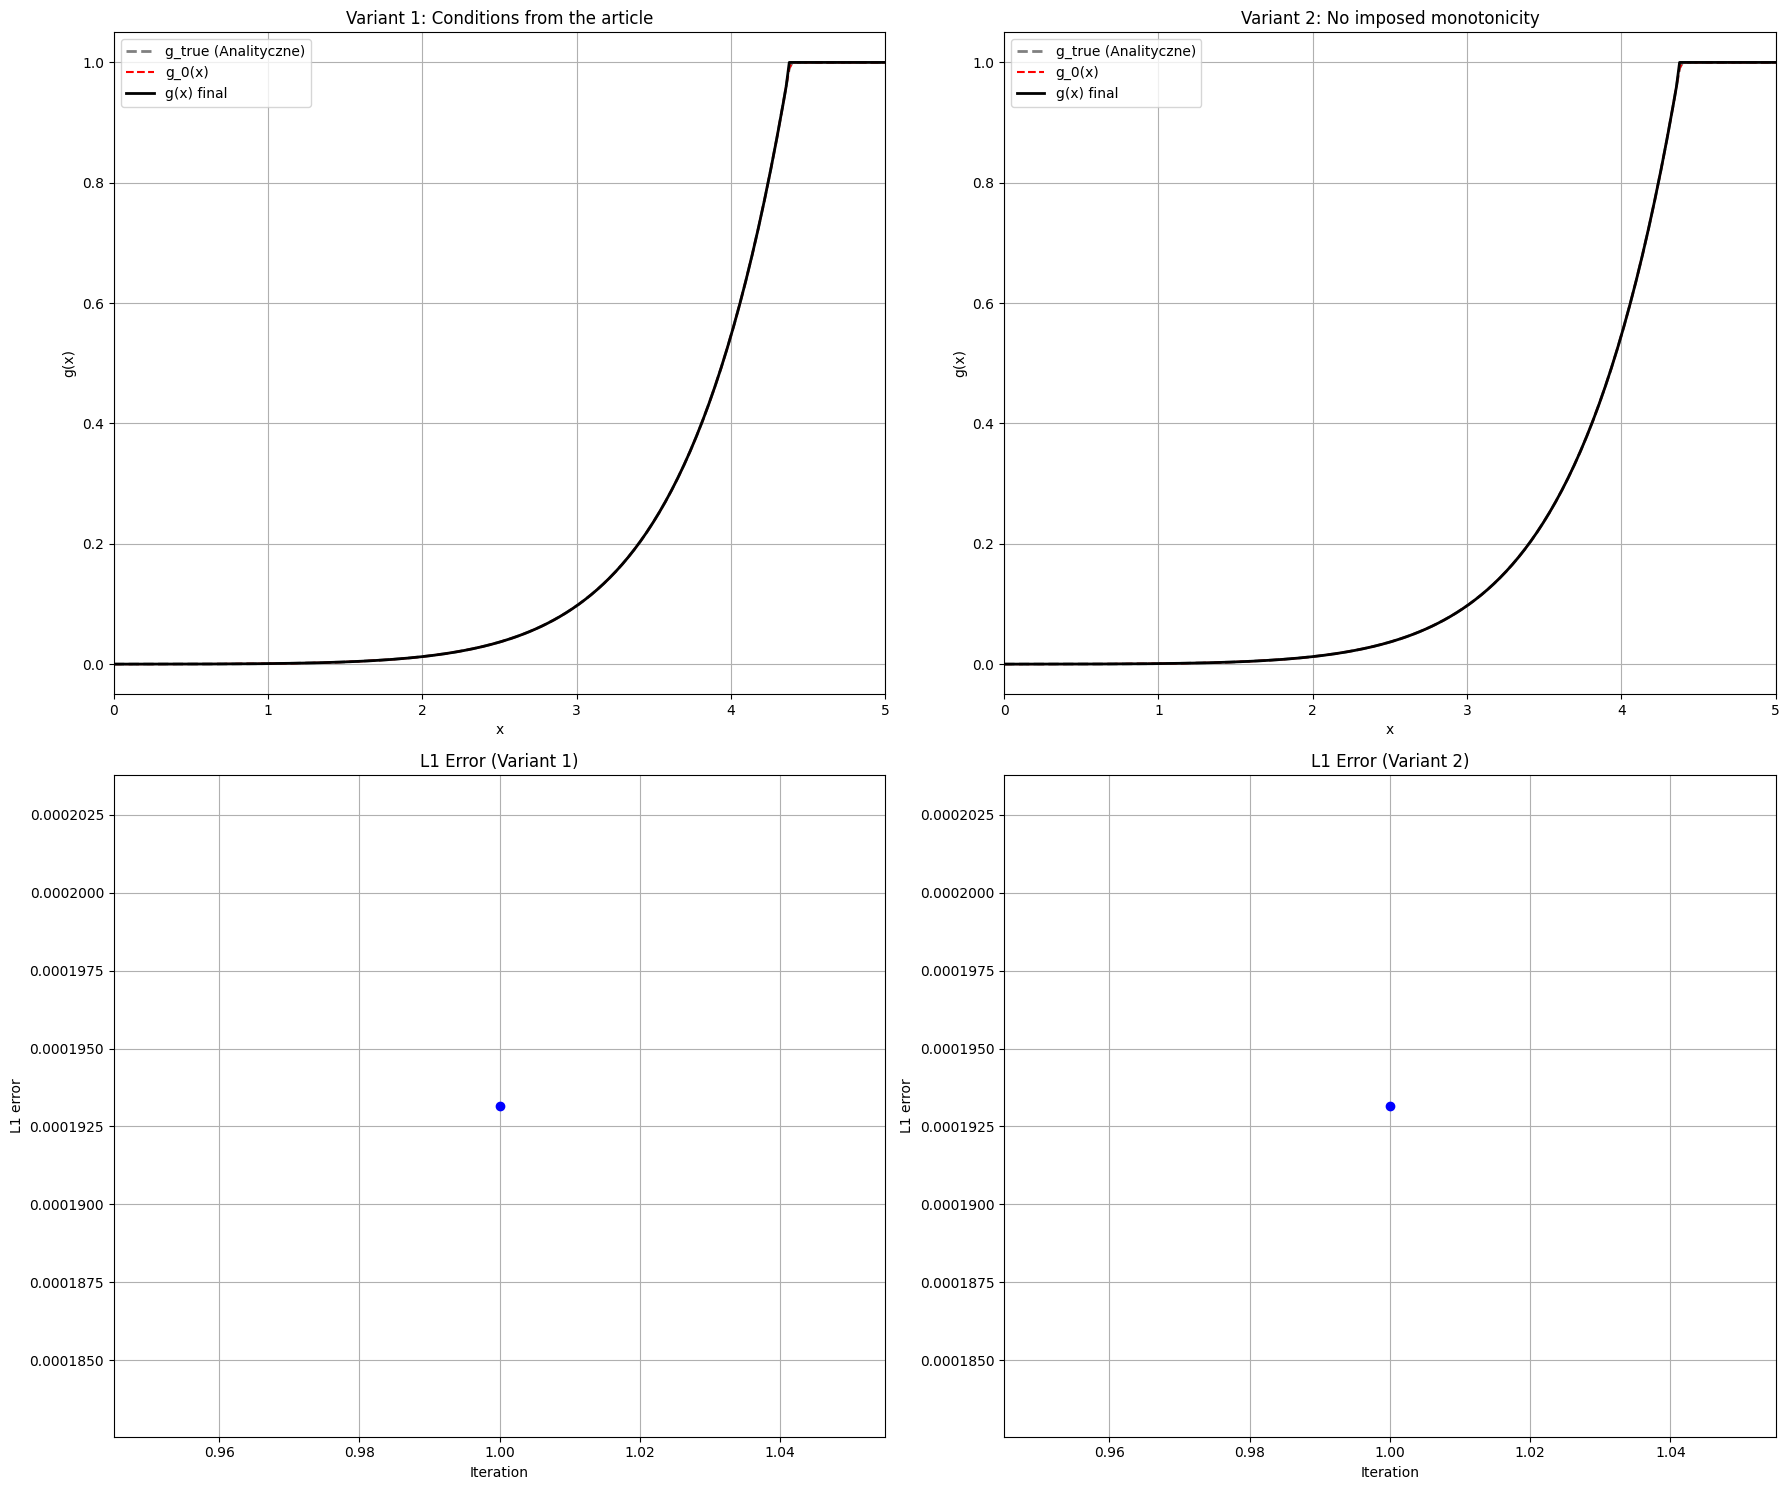

In [ ]:
run_algorithm_4(
    func_g_true, func_g_true, K=5, M=M, title_prefix="analytical initialization"
)

### linear initialization

Running calculations: linear initialization | Variant 1...
--- RESULTS FOR VARIANT 1 ---
Final L1 error:      1.171724
g_true reaches 1 at:    X = 4.3976
Model reaches 1 at:     X = 4.3574
-----------------------------------
Running calculations: linear initialization | Variant 2...
--- RESULTS FOR VARIANT 2 ---
Final L1 error:      0.572296
g_true reaches 1 at:    X = 4.3976
Model reaches 1 at:     X = 3.3334
-----------------------------------


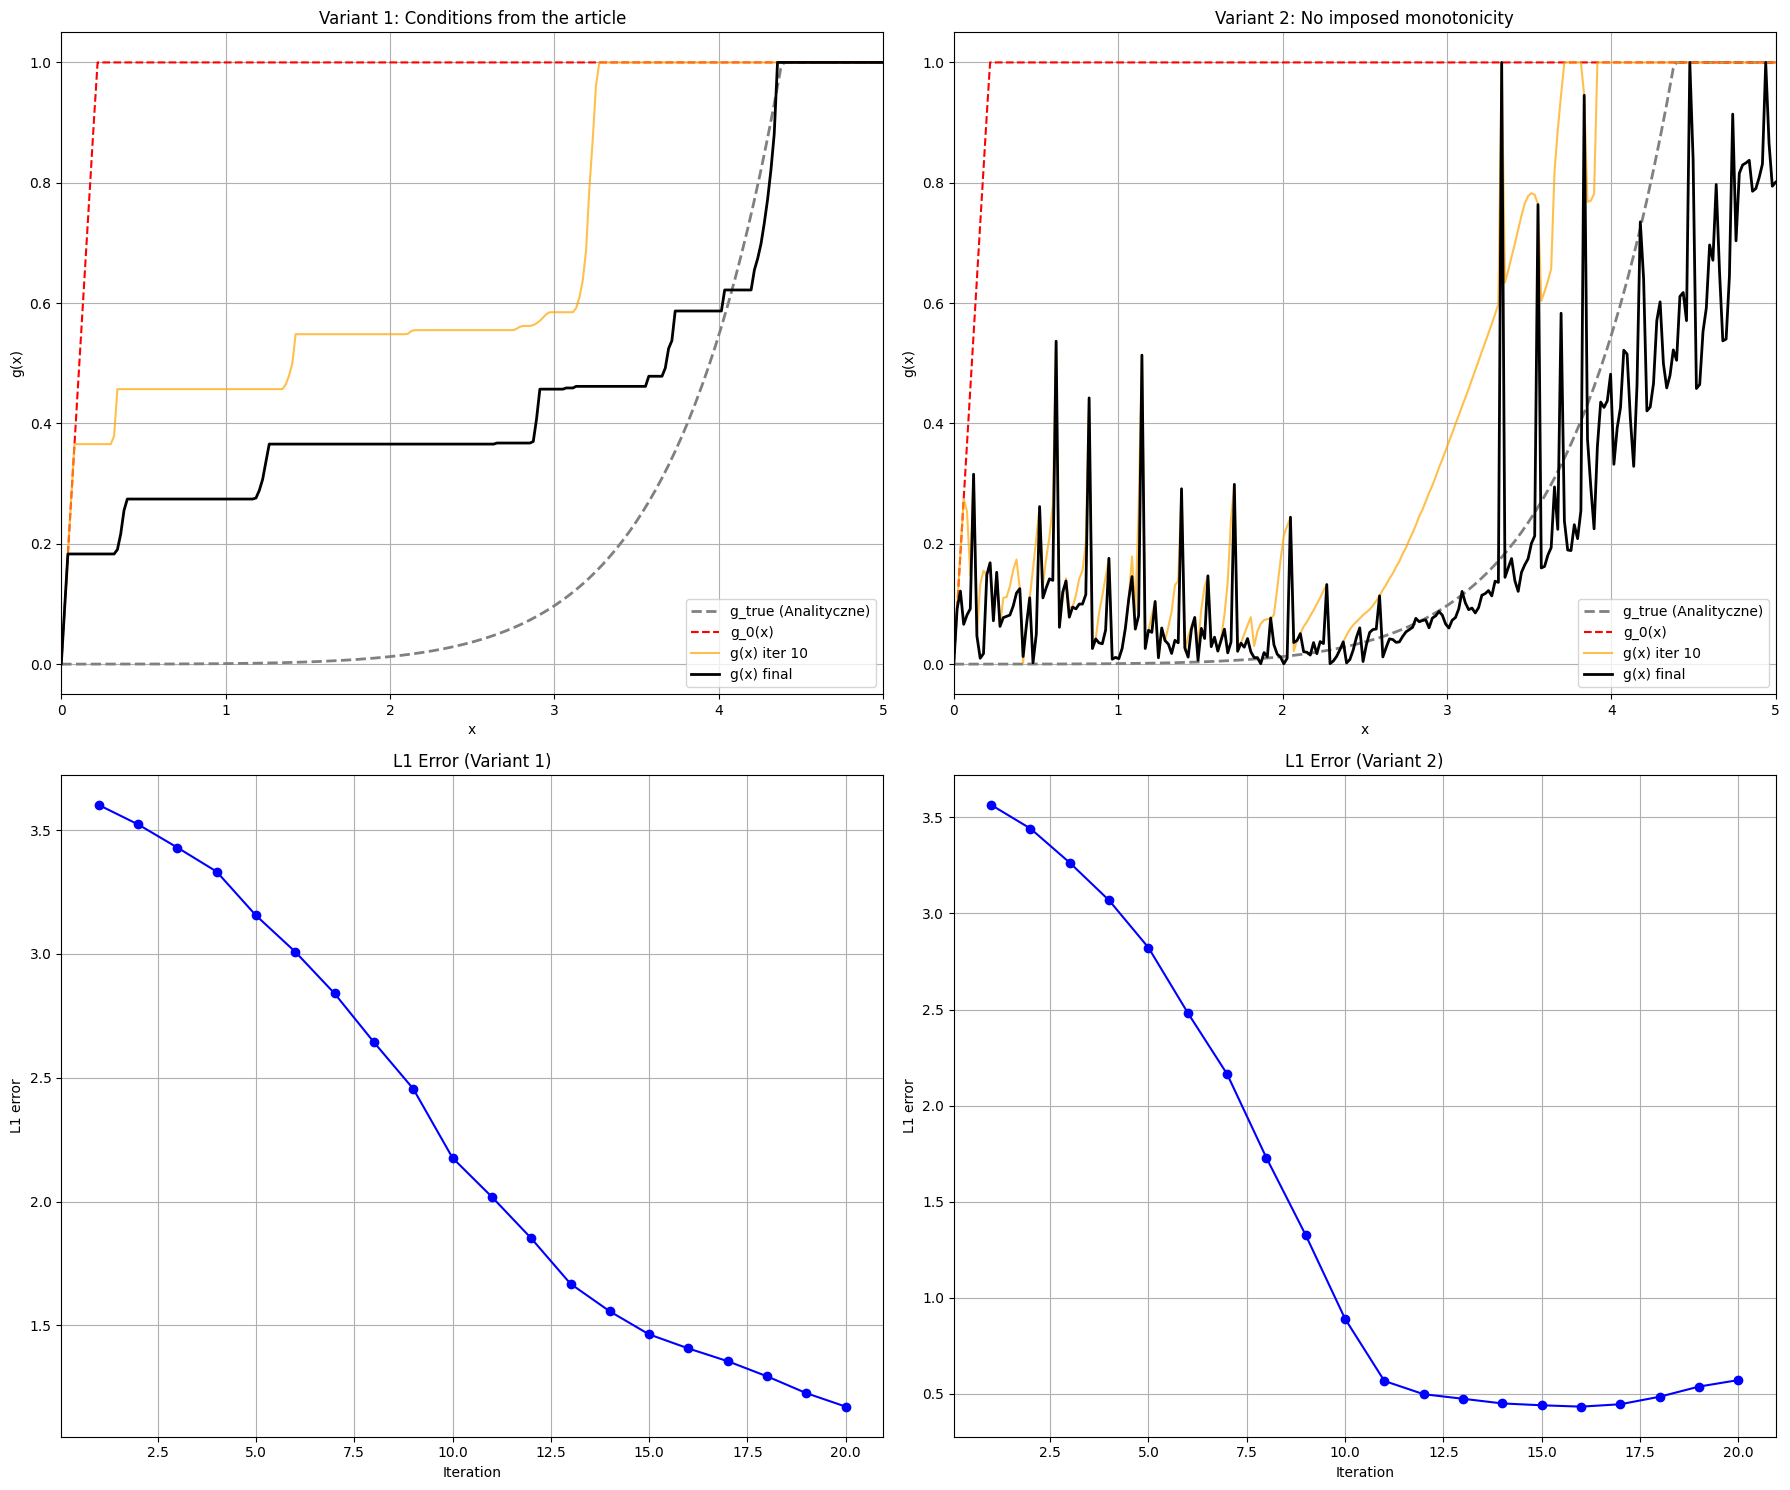

In [53]:
run_algorithm_4(
    func_linear, func_g_true, K=20, M=M, title_prefix="linear initialization"
)

### exponential initialization

In [ ]:
run_algorithm_4(
    func_exponential, func_g_true, K=20, M=M, title_prefix="exponential initialization"
)

Running calculations: exponential initialization | Variant 1...


## Conclusions

The model-free Policy Iteration (RL approach) experiments yield several important insights, especially when compared to the model-based exact solver (Algorithm 1):

1. **Model-Free Approximation:** The algorithm successfully approximates the theoretical boundary $g_{true}$ without any prior knowledge of the underlying system dynamics (PDEs) or parameters. Even with linear or exponential initialization, the agent manages to reshape the boundary to closely resemble the theoretical optimal stopping curve.

2. **Convergence and Monte Carlo Variance:** Unlike Algorithm 1, which often converges in around 8-11 iterations, Algorithm 4 requires more steps and typically hits the maximum iteration limit ($K=20$) for non-analytical initializations. This is an expected behavior in Reinforcement Learning. The value function here is estimated through Monte Carlo simulations (empirical averaging), which inherently introduces statistical noise and variance. This noise makes it difficult for the strict mathematical stopping criterion (gradient becoming exactly zero) to be perfectly satisfied, leading to longer optimization times.

3. **The Role of Forced Monotonicity:** We compared the boundary updates with forced monotonicity (Variant 1) and without it (Variant 2). While the unforced variant shows that the natural learning process roughly follows the theoretical shape, it is highly susceptible to local simulation noise. Enforcing monotonicity acts as a crucial mathematical regularizer. It ensures that the final boundary adheres to the theoretical properties of the optimal stopping problem, smoothing out the empirical noise and providing a much more robust and stable policy for the agent.